In [1]:
from matplotlib import pyplot as plt
from functions import *

# stop flow with reaction in 50 ul chip and PtOEP/DPA film
# blue 455 nm irradiation for tR, then uv-vis immediately after in the same chip
# flushed with fresh starting reaction mixture and repeated for new tR

# V(Ru(bpy)3, 12.5 mM, buffer) = 240 ul
# V(BV, 25 mM, buffer) = 720 ul
# V(EDTA, saturated, buffer) = 540 ul

data = f'./results/260715_Rubpy_BV_EDTA_PtOEP_DPA_Blue_StopFlow'

XV = r"[BV$^{+\!\cdot\!}$]" # [XV+.]
XV0 = r"[BV$^{2\!+\!}$]$_0$" # [XV2+]0
tR = "$t_\\mathrm{R}$" # tR
c0 = solprop(cstock=25e-3, valiquot=720e-6, vsol=1.5e-3) # initial XV2+ concentration
peak = 535 # nm
e = 1.4e6 # M-1 m-1
l = 700e-6 # m

tRs = [tR*30 for tR in range(1, 15)] # residence times in seconds for 1-7 minutes in 30s intervals

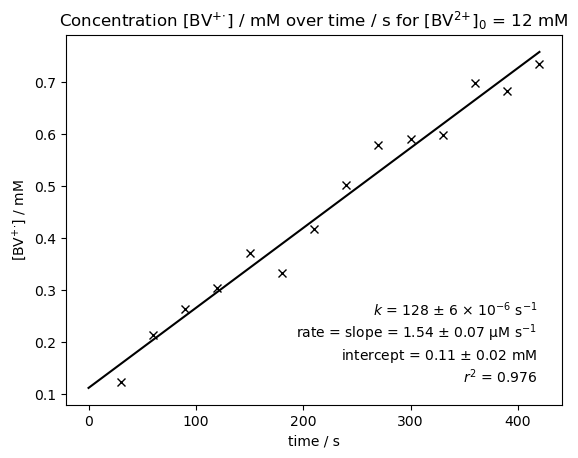

In [2]:
# concentration vs time plot for each run
c = concvstimepoints(data, peak, e, l)
plt.plot(tRs, [conc*1e3 for conc in c], 'x', color='black') # plot time in seconds, concentrations in μM

fit, i = linreg(tRs, c)
x = np.linspace(0, tRs[i], 100) # plot linear regression line over the initial linear region
y = (fit.slope*x + fit.intercept)*1e3
plt.plot(x, y, color='black')
plt.text(0.95, 0.05,
         rf'$k$ = {errformat(fit.slope/c0, fit.stderr/c0, prefix=1e-6)} $\times$ 10$^{{-6}}$ s$^{{-1}}$''\n'
         rf'rate = slope = {errformat(fit.slope, fit.stderr, prefix=1e-6)} µM s$^{{-1}}$''\n'
         f'intercept = {errformat(fit.intercept, fit.intercept_stderr, prefix=1e-3)} mM\n'
         f'$r^2$ = {fit.rvalue**2:.3f}',
         transform=plt.gca().transAxes, ha="right", va="bottom")

plt.xlabel(r'time / s')
plt.ylabel(rf'{XV} / mM')
plt.title(rf'Concentration {XV} / mM over time / s for {XV0} = {c0*1e3:.0f} mM')
plt.show()

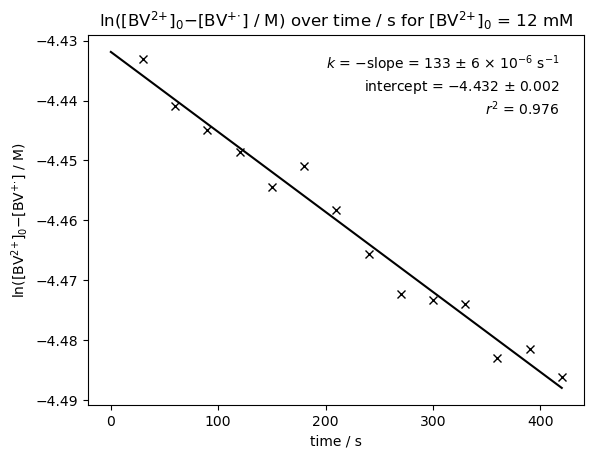

In [3]:
# ln vs time plot for each run
c = concvstimepoints(data, peak, e, l)
lnc = [np.log(c0-conc) for conc in c]
plt.plot(tRs, lnc, 'x', color='black') # plot time in seconds, concentrations in μM

fit, i = linreg(tRs, lnc)
x = np.linspace(0, tRs[i], 100) # plot linear regression line over the initial linear region
y = (fit.slope*x + fit.intercept)
plt.plot(x, y, color='black')
plt.text(0.95, 0.95,
         rf'$k$ = $-$slope = {errformat(-fit.slope, fit.stderr, prefix=1e-6)} $\times$ 10$^{{-6}}$ s$^{{-1}}$''\n'
         f'intercept = {errformat(fit.intercept, fit.intercept_stderr, sci=False)}\n'
         f'$r^2$ = {fit.rvalue**2:.3f}',
         transform=plt.gca().transAxes, ha="right", va="top")

plt.xlabel(r'time / s')
plt.ylabel(rf'ln({XV0}$-${XV} / M)')
plt.title(rf'ln({XV0}$-${XV} / M) over time / s for {XV0} = {c0*1e3:.0f} mM')
plt.show()

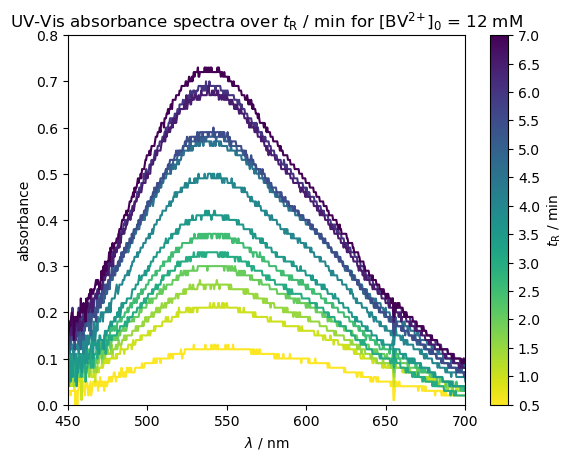

In [7]:
from matplotlib import cm as cm
from matplotlib import colors as colors

# absorbance spectra for each tR
fig, ax = plt.subplots()
cmap = plt.get_cmap("viridis_r")

l, a = spectrumvstimepoints(data)
for i in range(len(tRs)):
    ax.plot(l, a[i], color=cmap(i/(len(tRs)-1)))

norm = colors.Normalize(vmin=0, vmax=len(tRs)-1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_ticks(range(len(tRs)))
cbar.set_ticklabels([tR/60 for tR in tRs])
cbar.set_label(f"{tR} / min")

plt.title(rf'UV-Vis absorbance spectra over {tR} / min for {XV0} = {c0*1e3:.0f} mM')
plt.xlim(450, 700)
plt.ylim(0, 0.8)
plt.xlabel(r'$\lambda$ / nm')
plt.ylabel(r'absorbance')
plt.show()